In [817]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

## Uploading the DataSet  

In [818]:
data = pd.read_csv('DataSet/ChurnData.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [819]:
data.shape

(7043, 21)

In [820]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [821]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Cleaning
 
 check for Missing values

In [822]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


check for Duplicates

In [823]:

print(data.duplicated().sum())

0


## Transform the Data into Numerical Data

In [824]:
print(data['SeniorCitizen'].value_counts())

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [825]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
print((data['TotalCharges'].isnull().sum()))


11


In [826]:
#drop the rows with null values in TotalCharges column since it is only 11 rows and we can afford to lose them
data.dropna(inplace=True)
print(data.shape)

(7032, 21)


In [827]:
# Transform gender column to binary values
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})


In [828]:
# Transform all other categorical columns having more than or equal to 2 categories to one-hot encoded columns
categorical_cols = [col for col in data.columns if data[col].dtype == 'str' and data[col].nunique() >= 2 and data[col].nunique() < 5]

if('Churn' in categorical_cols):
    categorical_cols.remove('Churn')

data = pd.get_dummies(data, columns=categorical_cols,dtype=int,drop_first=True)

print(data.shape)

(7032, 32)


In [829]:
# Drop the customerID column since it is not useful for prediction and can cause overfitting
data.drop(['customerID'], axis=1, inplace=True)

In [830]:
data.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   tenure                                 7032 non-null   int64  
 3   MonthlyCharges                         7032 non-null   float64
 4   TotalCharges                           7032 non-null   float64
 5   Churn                                  7032 non-null   int64  
 6   Partner_Yes                            7032 non-null   int64  
 7   Dependents_Yes                         7032 non-null   int64  
 8   PhoneService_Yes                       7032 non-null   int64  
 9   MultipleLines_No phone service         7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetService_Fibe

## Check for Outliers 

In [831]:
def IQR_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if outliers.empty:
        print(f"No outliers found in {column}.")
        return pd.DataFrame()  # Return an empty DataFrame if no outliers are found
    else:
        print(f"Outliers in {column}:")
        print(outliers)
        return outliers

No outliers found in tenure.


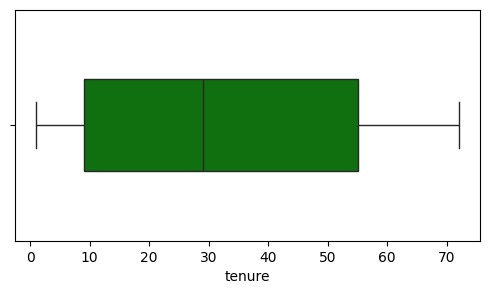

In [832]:
IQR_outliers(data, 'tenure')
plt.figure(figsize=(6, 3))
sns.boxplot(x=data['tenure'], color='green', width=0.4)
plt.show()


No outliers found in MonthlyCharges.


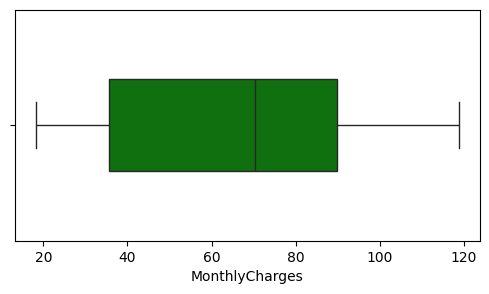

In [833]:
IQR_outliers(data, 'MonthlyCharges')
plt.figure(figsize=(6, 3))
sns.boxplot(x=data['MonthlyCharges'], color='green', width=0.4)
plt.show()

No outliers found in TotalCharges.


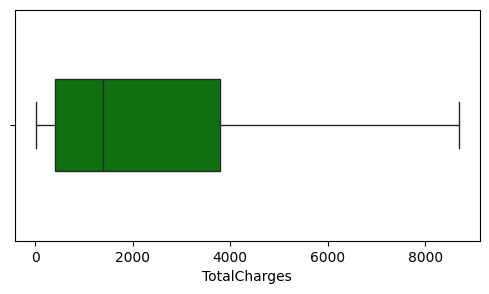

In [834]:
IQR_outliers(data, 'TotalCharges')
plt.figure(figsize=(6, 3))
sns.boxplot(x=data['TotalCharges'], color='green', width=0.4)
plt.show()

Normalize the Tenure,Montly Charges,Total Charges Using Min-Max Scalling

In [835]:
scaler = MinMaxScaler()
data['tenure'] = scaler.fit_transform(data[['tenure']])
data['MonthlyCharges'] = scaler.fit_transform(data[['MonthlyCharges']])
data['TotalCharges'] = scaler.fit_transform(data[['TotalCharges']])

## Plot the Distributions 

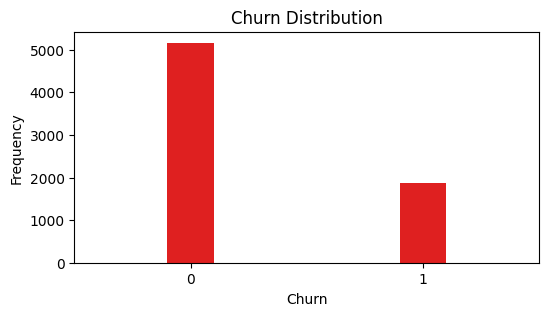

In [836]:
plt.figure(figsize=(6, 3))
sns.countplot(x=data['Churn'], color='red', width=0.2)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Frequency')
plt.show()

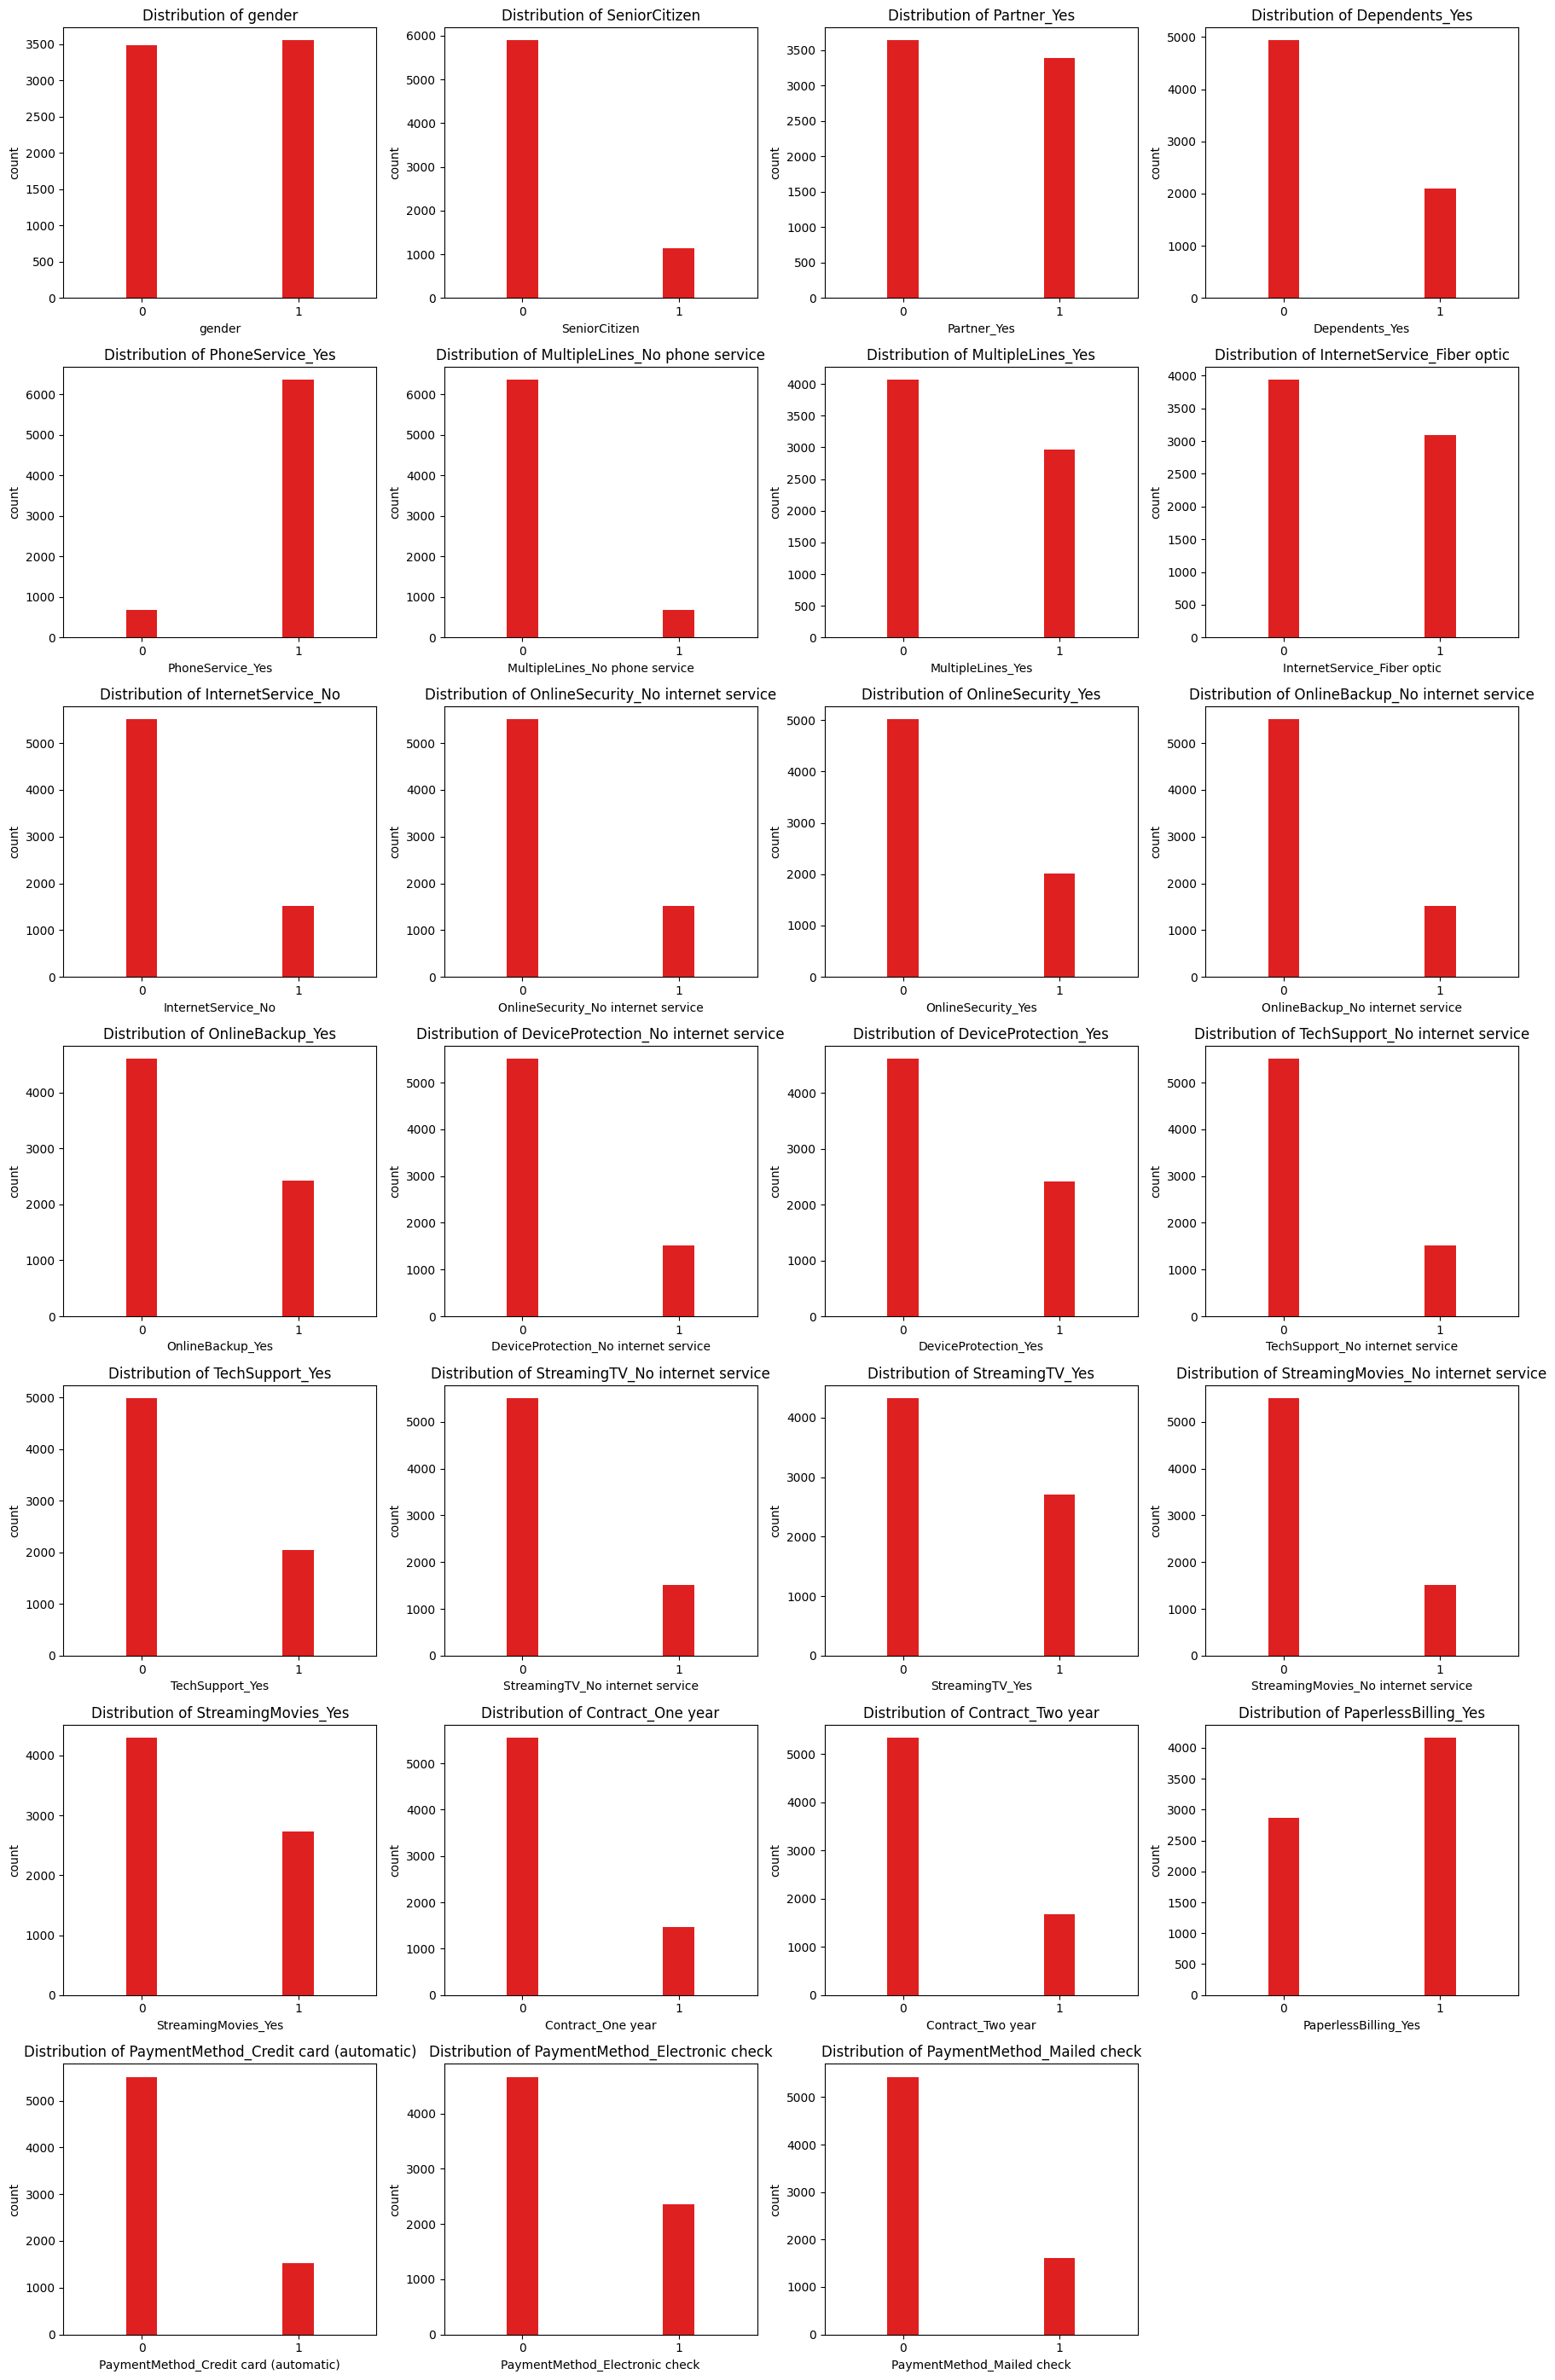

In [837]:
import math
int_cols = [col for col in data.columns if data[col].dtype == "int64"]
int_cols.remove('Churn')
# int_cols.remove('tenure')  
num_cols = 4
num_rows = math.ceil(len(int_cols) / num_cols)

plt.figure(figsize=(18, 4 * num_rows))

for i, col in enumerate(int_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.countplot( x=data[col], color="red",width=0.2)

    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()



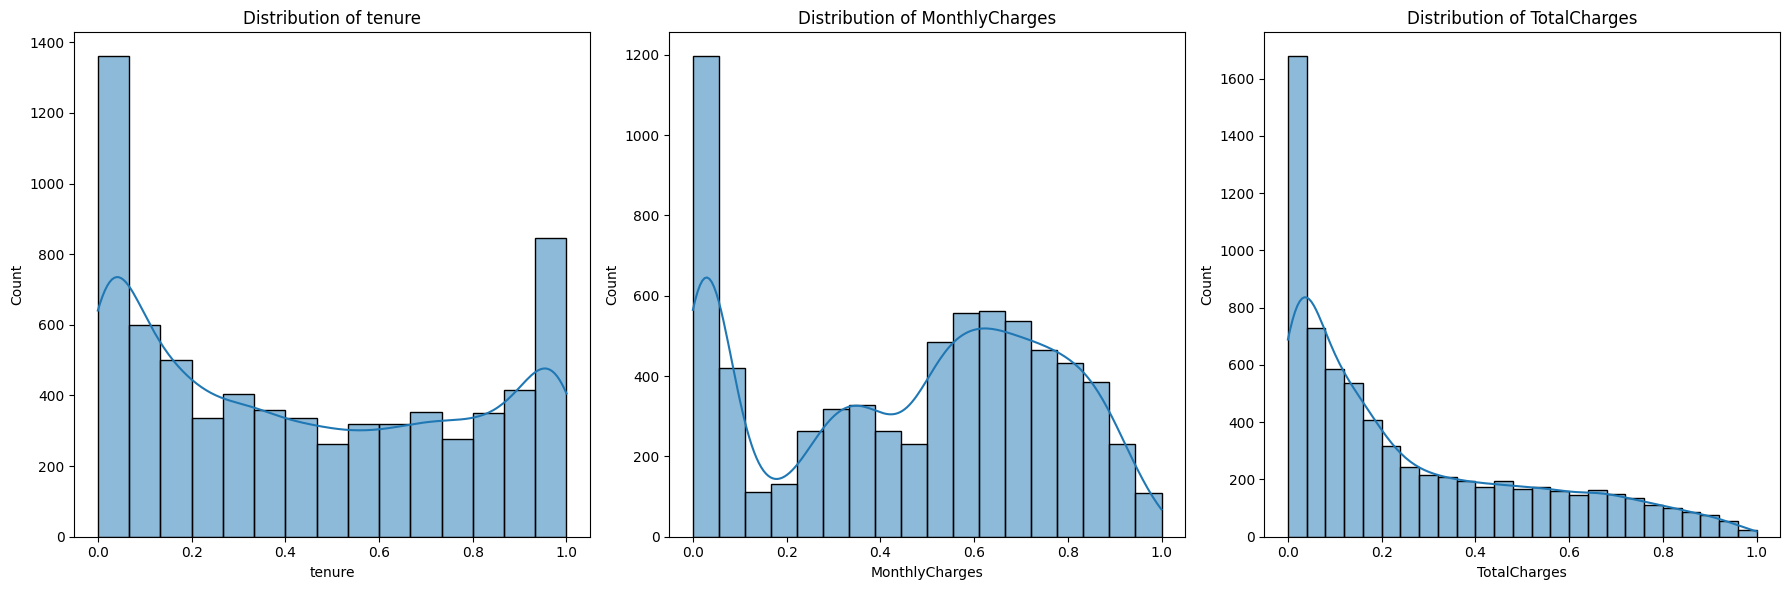

In [838]:
plt.figure(figsize=(18, 6))
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot( data[col],kde=True)
    plt.title(f"Distribution of {col}")   
plt.tight_layout()
plt.show()

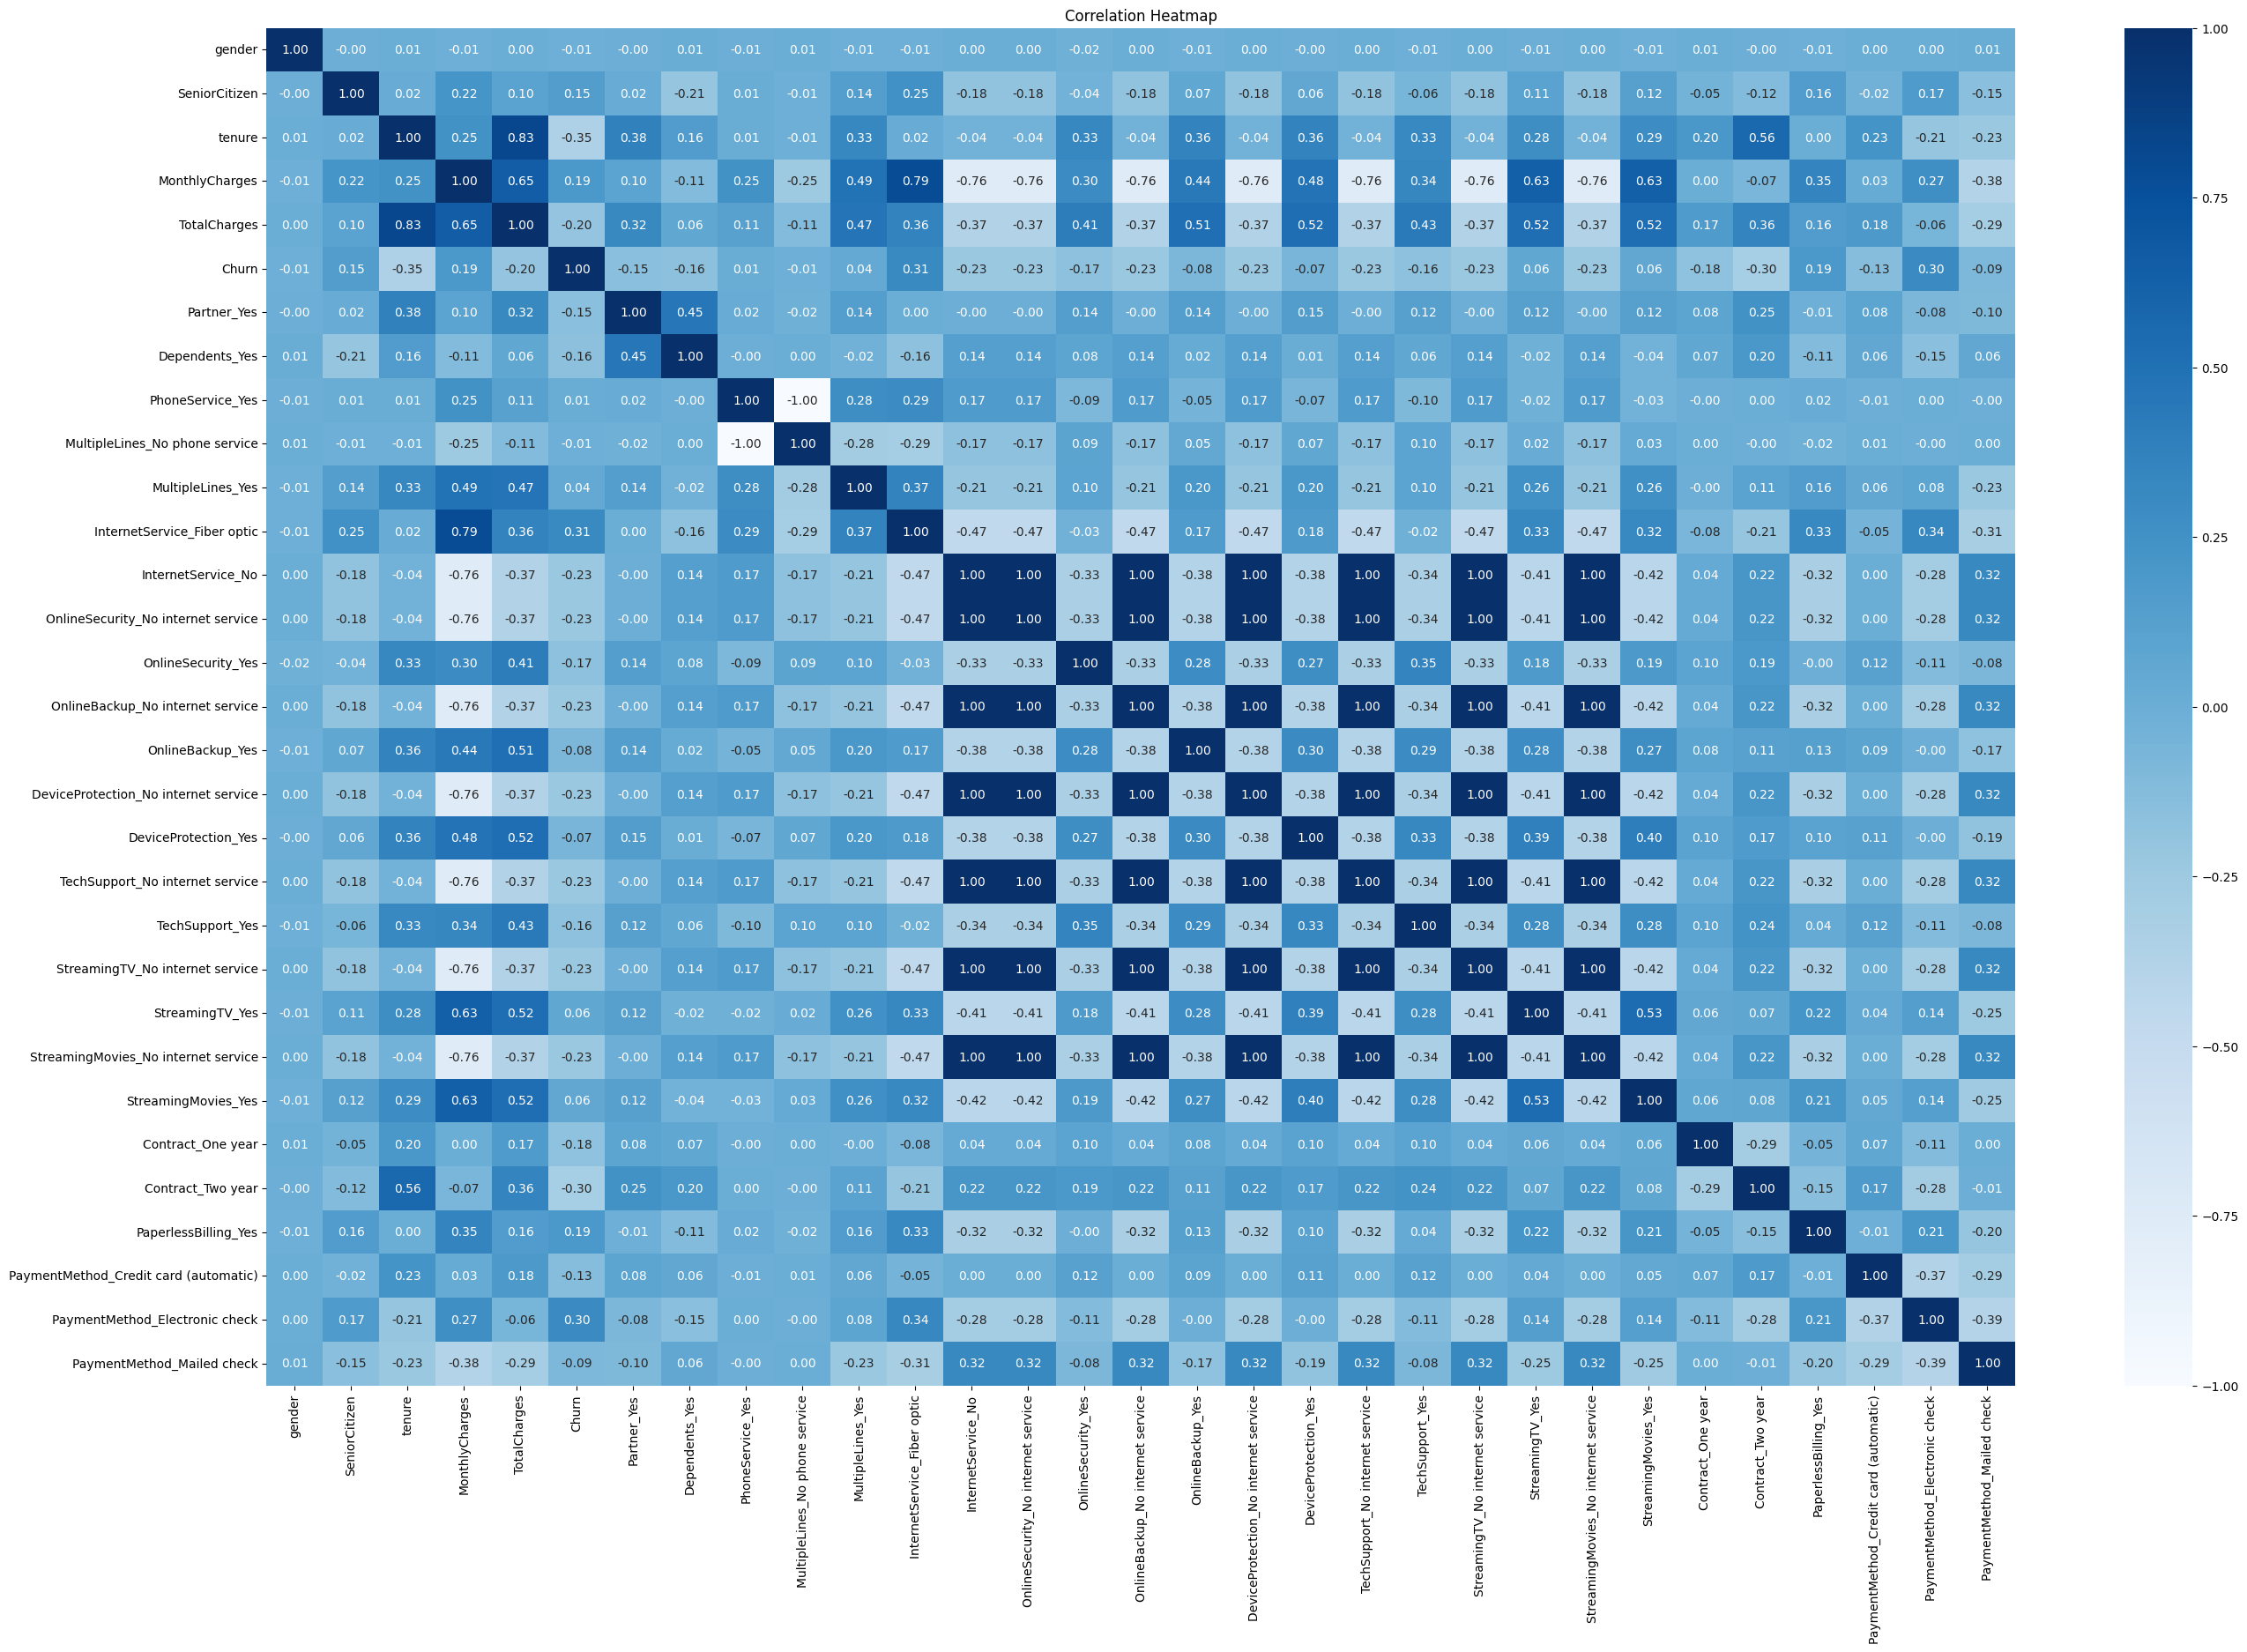

In [839]:
#Feature Selection
plt.figure(figsize=(32, 20))
sns.heatmap(data.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Split the Data Set into Train - test Data

In [840]:
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



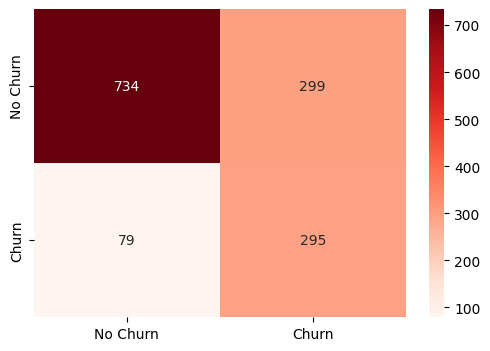

F1 Score:
0.609504132231405


In [841]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,f1_score

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.show()
print("F1 Score:")
print(f1_score(y_test, y_pred))

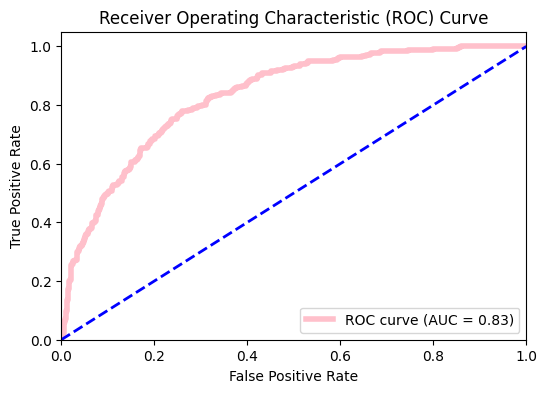

In [842]:
from sklearn.metrics import roc_curve, auc
y_pred_proba = model.predict_proba(X_test)[:, 1]
plt.figure(figsize=(6, 4))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='pink', lw=4, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

              precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.66      0.43      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407

Confusion Matrix:


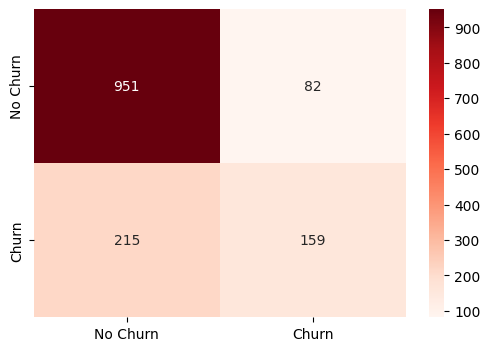

F1 Score:
0.5170731707317073


In [843]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.show()
print("F1 Score:")
print(f1_score(y_test, y_pred))

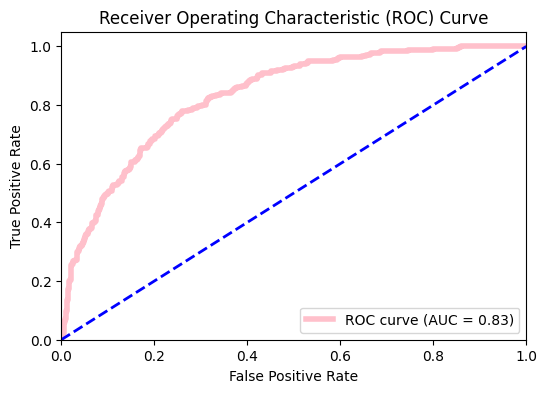

In [844]:
from sklearn.metrics import roc_curve, auc
y_pred_proba = model.predict_proba(X_test)[:, 1]
plt.figure(figsize=(6, 4))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='pink', lw=4, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()